<a href="https://colab.research.google.com/github/jatmoracruz-34/estadisticas-2026b/blob/main/Proyecto_Morales_Cruz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
import pandas as pd
link="https://raw.githubusercontent.com/jatmoracruz-34/estadisticas-2026b/refs/heads/main/bmw_global_sales_2018_2025.csv"
df = pd.read_csv(link)
df

,años,mes,region,modelo,Unidades_Vendidas,Precio_Promedio_EUR,Ingresos_EUR,Participación_BEV,Prima_Participación,Crecimiento_del_PBI,FÍndice de Precios de Combustible
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
...,...,...,...,...,...,...,...,...,...,...,...
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   años                               3072 non-null   int64  
 1   mes                                3072 non-null   int64  
 2   region                             3072 non-null   object 
 3   modelo                             3072 non-null   object 
 4   Unidades_Vendidas                  3072 non-null   int64  
 5   Precio_Promedio_EUR                3072 non-null   int64  
 6   Ingresos_EUR                       3072 non-null   int64  
 7   Participación_BEV                  3072 non-null   float64
 8   Prima_Participación                3072 non-null   float64
 9   Crecimiento_del_PBI                3072 non-null   float64
 10  FÍndice de Precios de Combustible  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ 

In [128]:
df.describe()

,años,mes,Unidades_Vendidas,Precio_Promedio_EUR,Ingresos_EUR,Participación_BEV,Prima_Participación,Crecimiento_del_PBI,FÍndice de Precios de Combustible
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


In [129]:
x=df["Precio_Promedio_EUR"]
y=df["Unidades_Vendidas"]

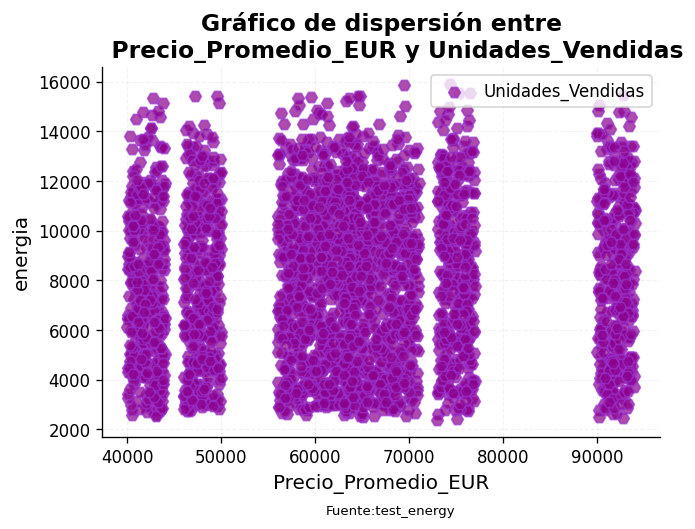

In [130]:
import matplotlib.pyplot as plt
plt.figure(
    figsize=(6, 4),
    dpi=120
)
plt.scatter(
    x, y,
    marker="H",
    color='#8B008B',
    edgecolor='#9932CC',
    alpha=0.7,
    s=50,
    label='Unidades_Vendidas'
)
plt.title(
    '''Gráfico de dispersión entre
    Precio_Promedio_EUR y Unidades_Vendidas''',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel(
    'Precio_Promedio_EUR',
    fontsize=12
)
plt.ylabel(
    'energia',
    fontsize=12
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.margins(x=0.05, y=0.05)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)
plt.text(
    0.4, -0.2,
    'Fuente:test_energy',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)
plt.savefig(
    "grafico de dispersión",
    bbox_inches='tight'
    )

plt.show()

In [131]:
from scipy.stats import pearsonr
r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.0392
Valor p:  0.0300


In [132]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,7438.550238
Precio_Promedio_EUR,0.008484


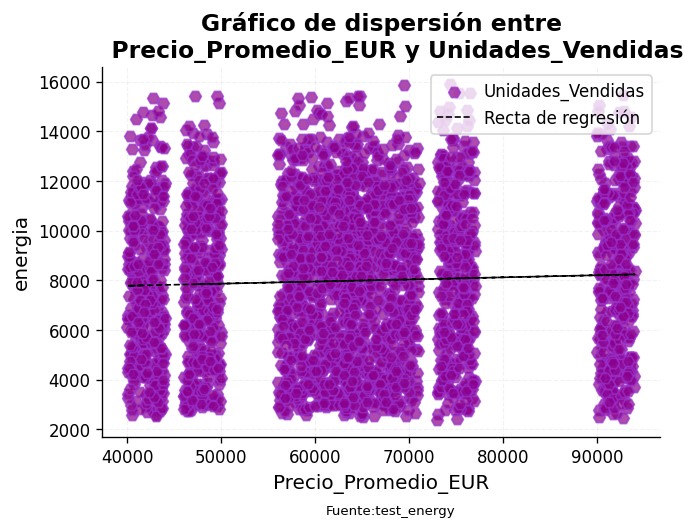

In [133]:
import matplotlib.pyplot as plt
plt.figure(
    figsize=(6, 4),
    dpi=120
)
plt.scatter(
    x, y,
    marker="H",
    color='#8B008B',
    edgecolor='#9932CC',
    alpha=0.7,
    s=50,
    label='Unidades_Vendidas'
)
plt.plot(
    x, y_calculada,
    color='black',
    linewidth=1,
    linestyle='--',
    marker='o',
    markersize=0,
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)
plt.title(
    '''Gráfico de dispersión entre
    Precio_Promedio_EUR y Unidades_Vendidas''',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel(
    'Precio_Promedio_EUR',
    fontsize=12
)
plt.ylabel(
    'energia',
    fontsize=12
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.margins(x=0.05, y=0.05)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)
plt.text(
    0.4, -0.2,
    'Fuente:test_energy',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)
plt.savefig(
    "grafico de dispersión",
    bbox_inches='tight'
    )

plt.show()

In [134]:
from sklearn.metrics import r2_score
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  0.15%



In [135]:
modelo.conf_int(alpha = 0.05)

,0,1
const,6936.700730,7940.399746
Precio_Promedio_EUR,0.000824,0.016144


In [136]:
residuales = modelo.resid

residuales

,0
0,-19.384364
1,2318.118330
2,-4829.291919
3,-595.075933
4,252.382708
...,...
3067,1263.862471
3068,4567.293802
3069,-3070.745522
3070,-194.232947


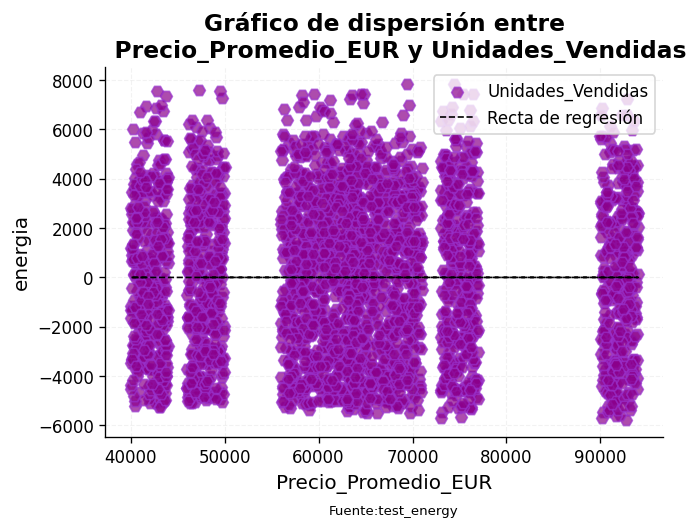

In [137]:
import matplotlib.pyplot as plt
plt.figure(
    figsize=(6, 4),
    dpi=120
)
plt.scatter(
    x, residuales,
    marker="H",
    color='#8B008B',
    edgecolor='#9932CC',
    alpha=0.7,
    s=50,
    label='Unidades_Vendidas'
)
plt.plot(
    x, 0 * y_calculada,
    color='black',
    linewidth=1,
    linestyle='--',
    marker='o',
    markersize=0,
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)
plt.title(
    '''Gráfico de dispersión entre
    Precio_Promedio_EUR y Unidades_Vendidas''',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel(
    'Precio_Promedio_EUR',
    fontsize=12
)
plt.ylabel(
    'energia',
    fontsize=12
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.margins(x=0.05, y=0.05)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)
plt.text(
    0.4, -0.2,
    'Fuente:test_energy',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)
plt.savefig(
    "grafico de dispersión",
    bbox_inches='tight'
    )

plt.show()

valor-p (Shapiro) = 4.156162515019361e-25


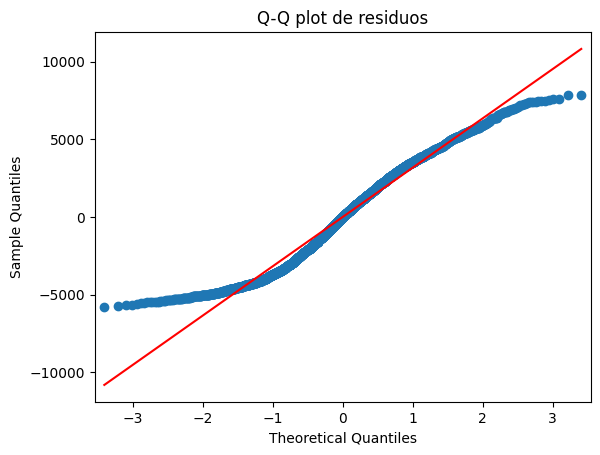

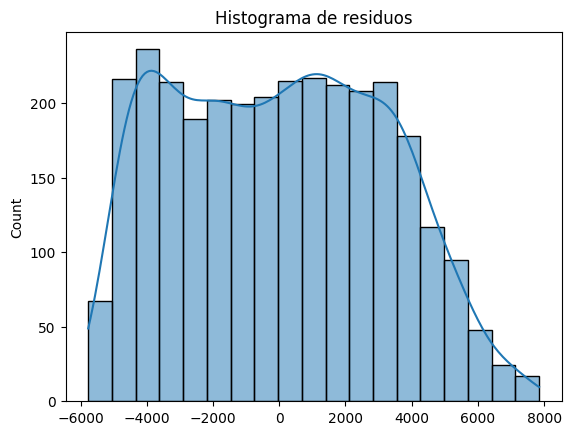

In [138]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [139]:
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2705



In [140]:
modelo.predict([25881,920000])

array([1.92524924e+08])

In [141]:
from statsmodels.formula.api import ols
modelo_lineal = ols('Unidades_Vendidas ~ Precio_Promedio_EUR', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Precio_Promedio_EUR,1.0,4.747870e+07,4.747870e+07,4.71584,0.029962
Residual,3070.0,3.090851e+10,1.006792e+07,NaN,NaN
